# 2.1 Tabular vs Sequential 데이터 차이 — 실습

> 이론 자료(`01_tabular_vs_sequential.md`)를 읽은 직후에 실행합니다.
>
> **이번 실습이 답하는 질문**
> 1. 현재 프로젝트의 tabular 배열 `X_is.shape = (N, 17)` 은 실제로 어떤 모양인가?
> 2. 이것을 `(N', T, 17)` sequential 배열로 바꾸는 과정은 구체적으로 어떻게 생겼는가?
> 3. T=60으로 변환하면 샘플이 몇 개가 사라지는가?
> 4. Sequential 샘플 하나는 tabular 한 행보다 얼마나 "정보량"이 큰가?

MSFT 한 종목으로 진행합니다 (패널 전체는 2.4에서 DataLoader로 처리).


## Step 0 — 환경 설정

CLAUDE.md 지침에 따라 matplotlib 한글 폰트를 OS별로 분기 처리합니다.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform
import warnings

warnings.filterwarnings('ignore')

# ─── 한글 폰트 설정 (CLAUDE.md 지침) ────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    try:
        import koreanize_matplotlib  # pip install koreanize-matplotlib
    except ImportError:
        pass
plt.rcParams['axes.unicode_minus'] = False

print(f'numpy  {np.__version__}')
print(f'pandas {pd.__version__}')
print(f'OS     {platform.system()}')

numpy  2.4.4
pandas 2.3.3
OS     Windows


## Step 1 — 데이터 로드 및 17개 피처 선정

현재 Black-Litterman 프로젝트(`Step3_IT_WalkForward_panel.ipynb`)와 **같은 피처 목록**을 사용합니다.
이렇게 해야 이번 실습에서 만든 sequential 구조를 그대로 3주차 GRU에 흘려 넣을 수 있습니다.

In [4]:
CSV = '../../black_litterman/data/panels/MSFT.csv'

# 프로젝트 원본과 동일한 17개 피처
FEATURE_COLS = [
    'log_return_1d', 'simple_return_1d',
    'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m', 'mom_12m_skip_1m',
    'vol_20d_ann', 'vol_60d_ann', 'vol_252d_ann',
    'mkt_rf', 'smb', 'hml', 'rmw', 'cma', 'rf', 'mom_factor',
]
DATA_START = pd.Timestamp('2020-12-01')
DATA_END   = pd.Timestamp('2025-12-31')

df = pd.read_csv(CSV, index_col='date', parse_dates=True)
df = df[(df.index >= DATA_START) & (df.index <= DATA_END)]
df = df.dropna(subset=FEATURE_COLS)  # 보수적: 피처 결측이 있는 날은 제외

print(f'MSFT 기간   : {df.index.min().date()} ~ {df.index.max().date()}')
print(f'유효 일수   : {len(df)}')
print(f'피처 개수   : {len(FEATURE_COLS)}')
print()
print('상단 3행 (피처만):')
df[FEATURE_COLS].head(3)

MSFT 기간   : 2020-12-01 ~ 2025-12-30
유효 일수   : 1276
피처 개수   : 17

상단 3행 (피처만):


,log_return_1d,simple_return_1d,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_skip_1m,vol_20d_ann,vol_60d_ann,vol_252d_ann,mkt_rf,smb,hml,rmw,cma,rf,mom_factor
date,,,,,,,,,,,,,,,,,
2020-12-01,0.009947,0.009997,0.070658,-0.046174,0.172314,0.461053,0.364631,0.300911,0.324721,0.439140,0.0099,-0.0006,0.0052,0.0104,0.0053,0.0,-0.0078
2020-12-02,-0.003893,-0.003885,0.067236,-0.067844,0.183336,0.457715,0.365879,0.295332,0.303350,0.439162,0.0011,0.0021,0.0107,0.0037,0.0055,0.0,-0.0223
2020-12-03,-0.005261,-0.005247,0.040551,-0.011501,0.150214,0.444842,0.388536,0.243816,0.291511,0.439209,0.0017,0.0056,-0.0010,-0.0027,0.0020,0.0,-0.0056


## Step 2 — Tabular 배열

현재 XGBoost가 보는 방식입니다. 각 행은 **하루치 관측**이고, 행끼리는 독립 가정.

In [5]:
X_tab = df[FEATURE_COLS].to_numpy(dtype=np.float32)

print(f'X_tab.shape = {X_tab.shape}')
print(f'  - 첫 번째 차원 {X_tab.shape[0]:>5d} = 관측 일수 (행)')
print(f'  - 두 번째 차원 {X_tab.shape[1]:>5d} = 피처 수')
print()
print('X_tab[0] (첫날의 17개 수치):')
print(X_tab[0])
print()
print('메모리 사용량:', f'{X_tab.nbytes / 1024:.1f} KB')

X_tab.shape = (1276, 17)
  - 첫 번째 차원  1276 = 관측 일수 (행)
  - 두 번째 차원    17 = 피처 수

X_tab[0] (첫날의 17개 수치):
[ 0.00994708  0.00999672  0.0706578  -0.04617368  0.17231385  0.4610525
  0.3646307   0.30091056  0.3247205   0.43914017  0.0099     -0.0006
  0.0052      0.0104      0.0053      0.         -0.0078    ]

메모리 사용량: 84.7 KB


## Step 3 — Sliding Window 로 Sequential 배열 만들기

$(N, F) \to (N', T, F)$ 변환은 "하루씩 밀면서 과거 T일을 묶는" 작업입니다.

```
t=0:  [row_0,  row_1,  ..., row_{T-1}]   → 샘플 0
t=1:  [row_1,  row_2,  ..., row_T    ]   → 샘플 1
t=2:  [row_2,  row_3,  ..., row_{T+1}]   → 샘플 2
...
```

stride=1이므로 인접 샘플끼리 T−1 일치 데이터가 겹칩니다.
처음 T−1 개 시점은 "과거가 모자라서" 샘플을 못 만들므로 잘려나갑니다.

In [6]:
def make_sequences(arr: np.ndarray, T: int) -> np.ndarray:
    '''
    Tabular 배열 (N, F) 을 Sequential 배열 (N-T+1, T, F) 로 변환.
    stride=1 (한 스텝씩 이동), 겹치는 윈도우.

    NOTE: 2.2에서 np.lib.stride_tricks.sliding_window_view 를 이용한
         O(1) 메모리 버전을 배울 예정. 여기선 명시적 복사 버전.
    '''
    N, F = arr.shape
    if N < T:
        raise ValueError(f'샘플이 부족합니다: N={N} < T={T}')
    out = np.empty((N - T + 1, T, F), dtype=arr.dtype)
    for i in range(N - T + 1):
        out[i] = arr[i : i + T]
    return out

T = 60   # lookback window (약 3개월치 거래일)
X_seq = make_sequences(X_tab, T)

print(f'Tabular    : X_tab.shape = {X_tab.shape}')
print(f'Sequential : X_seq.shape = {X_seq.shape}   ← (N\', T, F)')
print()
print('차원 의미:')
print(f'  - 첫 번째  {X_seq.shape[0]:>5d} = 샘플 수 (N\')')
print(f'  - 두 번째  {X_seq.shape[1]:>5d} = lookback 길이 T')
print(f'  - 세 번째  {X_seq.shape[2]:>5d} = 피처 수 F')

Tabular    : X_tab.shape = (1276, 17)
Sequential : X_seq.shape = (1217, 60, 17)   ← (N', T, F)

차원 의미:
  - 첫 번째   1217 = 샘플 수 (N')
  - 두 번째     60 = lookback 길이 T
  - 세 번째     17 = 피처 수 F


## Step 4 — 두 방식의 "같은 시점" 매핑

Sequential 샘플 `i` 는 "`df.index[i]` 부터 `df.index[i+T-1]` 까지의 T일 묶음" 입니다.
즉 샘플 `i` 의 **마지막 행**은 tabular의 행 `i + T - 1` 과 같아야 합니다.

이걸 직접 확인해두면, 2.3에서 "오늘 X → 다음달 수익률 y" 로 레이블을 붙일 때 헷갈리지 않습니다.

In [7]:
# 임의의 시퀀스 샘플 하나 선택
sample_idx = 100

seq_last_row = X_seq[sample_idx, -1, :]   # Sequential 샘플의 마지막 시점
tab_row      = X_tab[sample_idx + T - 1, :]  # 같은 날의 tabular 행

date_start = df.index[sample_idx]
date_end   = df.index[sample_idx + T - 1]

print(f'Sequential 샘플 #{sample_idx}:')
print(f'  lookback 시작 : {date_start.date()}  (df.index[{sample_idx}])')
print(f'  "오늘"         : {date_end.date()}  (df.index[{sample_idx + T - 1}])')
print(f'  T={T}일 범위에 {T}개의 거래일 포함')
print()
print(f'  X_seq[{sample_idx}, -1, :] == X_tab[{sample_idx + T - 1}, :] ?')
print(f'  → {np.allclose(seq_last_row, tab_row)}')

Sequential 샘플 #100:
  lookback 시작 : 2021-04-27  (df.index[100])
  "오늘"         : 2021-07-21  (df.index[159])
  T=60일 범위에 60개의 거래일 포함

  X_seq[100, -1, :] == X_tab[159, :] ?
  → True


## Step 5 — Sequential 샘플 한 개를 시각화

한 샘플은 `(T, F) = (60, 17)` 크기의 2D 블록입니다. Heatmap 한 장으로 통째로 볼 수 있습니다.

해석 팁:
- 가로축 = 시점 (lookback 내 상대 위치, 0 = 60일 전, 59 = 오늘)
- 세로축 = 17개 피처
- 색       = 표준화된 값 (피처별 z-score; 시각화만 표준화해서 크기 스케일 차이를 중화)

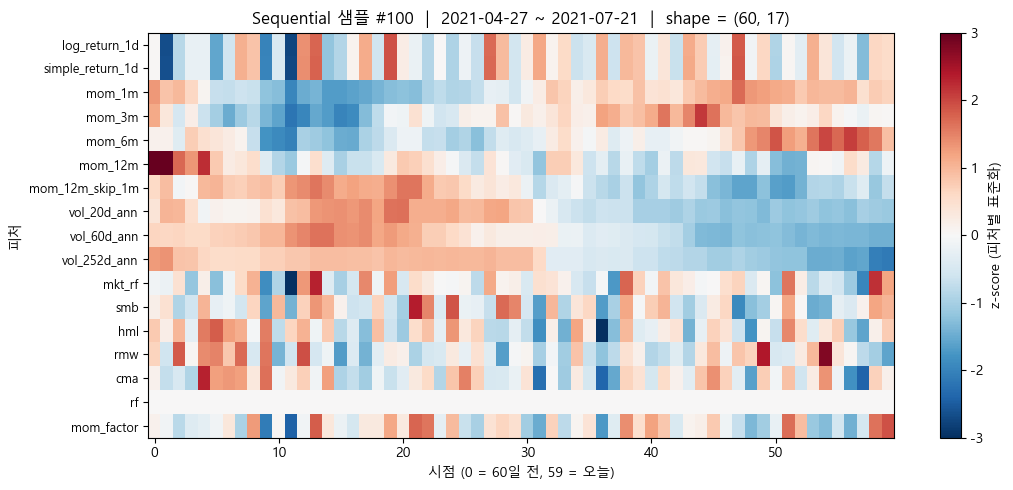


이 그림 한 장이 Sequential 샘플 1개입니다.
숫자 개수: 1020 = T(60) × F(17)


In [8]:
# 시각화 대상 샘플
sample_idx = 100
block = X_seq[sample_idx]  # shape (T, F) = (60, 17)

# 피처별 z-score 표준화 (시각화용 — 실제 학습에서 쓰는 스케일링과는 별개)
block_z = (block - block.mean(axis=0)) / (block.std(axis=0) + 1e-8)

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(
    block_z.T,          # (F, T) 로 전치: 세로=피처, 가로=시점
    aspect='auto',
    cmap='RdBu_r',
    vmin=-3, vmax=3,
    interpolation='nearest',
)
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=9)
ax.set_xlabel(f'시점 (0 = {T}일 전, {T-1} = 오늘)')
ax.set_ylabel('피처')
ax.set_title(
    f'Sequential 샘플 #{sample_idx}  |  '
    f'{df.index[sample_idx].date()} ~ {df.index[sample_idx + T - 1].date()}  '
    f'|  shape = {block.shape}'
)
plt.colorbar(im, ax=ax, label='z-score (피처별 표준화)')
plt.tight_layout()
plt.show()

print()
print('이 그림 한 장이 Sequential 샘플 1개입니다.')
print(f'숫자 개수: {block.size} = T({T}) × F({len(FEATURE_COLS)})')

## Step 6 — Tabular 한 행 vs Sequential 한 샘플 — "정보량" 비교

Tabular 한 행은 위 heatmap의 **마지막 세로줄 하나**만 보는 것과 같습니다.
Sequential은 그 세로줄을 만들기까지의 **흐름**을 전부 같이 봅니다.

아래 3개 대표 피처의 시계열 궤적을 보여주면 감이 확실히 잡힙니다.

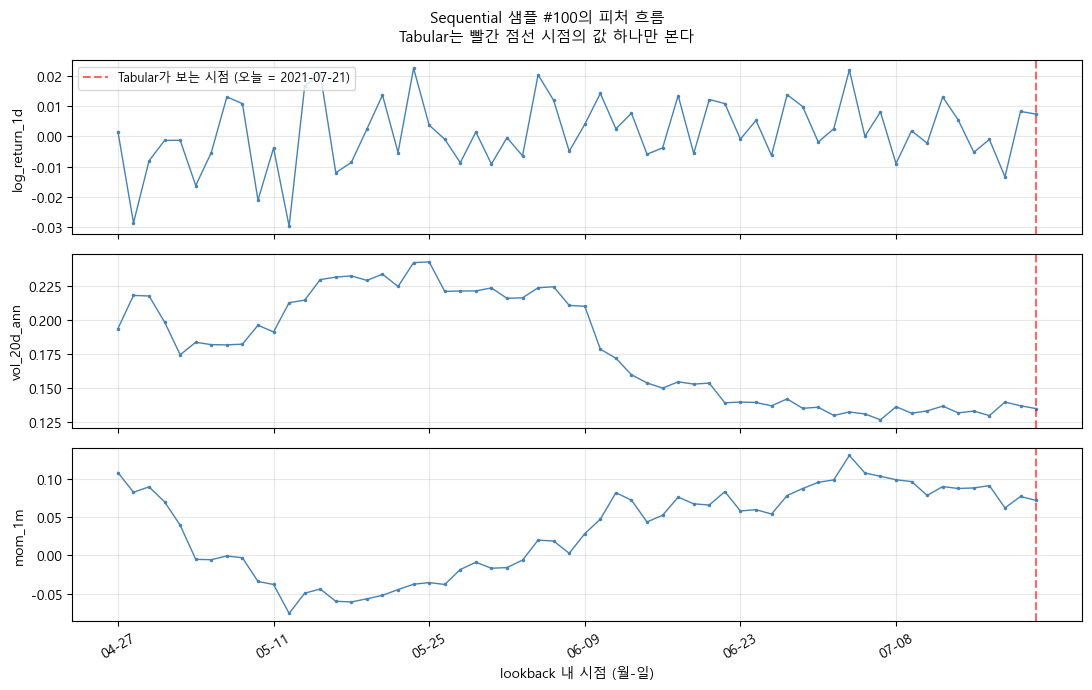

핵심 포인트
  - Tabular 모델은 오늘(2021-07-21)의 17개 값만 봄
  - Sequential 모델은 지난 60일간의 궤적을 본다
    → "지난 60일간 변동성이 상승 중인가 하락 중인가" 같은 동적 패턴 학습 가능


In [9]:
demo_feats = ['log_return_1d', 'vol_20d_ann', 'mom_1m']
demo_idx   = [FEATURE_COLS.index(f) for f in demo_feats]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
x_axis = np.arange(T)
date_labels = [d.strftime('%m-%d') for d in df.index[sample_idx : sample_idx + T]]

for ax, f, fi in zip(axes, demo_feats, demo_idx):
    series = X_seq[sample_idx, :, fi]
    ax.plot(x_axis, series, marker='.', markersize=3, linewidth=1.0, color='steelblue')
    ax.axvline(T - 1, color='red', linestyle='--', alpha=0.6,
               label=f'Tabular가 보는 시점 (오늘 = {df.index[sample_idx+T-1].date()})')
    ax.set_ylabel(f)
    ax.grid(alpha=0.3)
    if f == demo_feats[0]:
        ax.legend(loc='upper left', fontsize=9)

axes[-1].set_xticks(np.arange(0, T, 10))
axes[-1].set_xticklabels([date_labels[i] for i in range(0, T, 10)], rotation=30)
axes[-1].set_xlabel('lookback 내 시점 (월-일)')
fig.suptitle(
    f'Sequential 샘플 #{sample_idx}의 피처 흐름\n'
    f'Tabular는 빨간 점선 시점의 값 하나만 본다',
    fontsize=11
)
plt.tight_layout()
plt.show()

print('핵심 포인트')
print(f'  - Tabular 모델은 오늘({df.index[sample_idx+T-1].date()})의 17개 값만 봄')
print(f'  - Sequential 모델은 지난 {T}일간의 궤적을 본다')
print(f'    → "지난 {T}일간 변동성이 상승 중인가 하락 중인가" 같은 동적 패턴 학습 가능')

## Step 7 — 샘플 수 손실 정리

처음 `T-1` 일은 "과거 60일이 없어서" sequential 샘플을 만들 수 없습니다.
이번 MSFT 단일 종목에선 다음과 같이 바뀝니다.

In [10]:
n_tab = X_tab.shape[0]
n_seq = X_seq.shape[0]
loss = n_tab - n_seq

print(f'Tabular 샘플 수     (일수) : {n_tab:>5d}')
print(f'Sequential 샘플 수 (T={T}) : {n_seq:>5d}')
print(f'손실                         : {loss:>5d} 일  ({loss/n_tab*100:.1f}%)')
print()

# 다양한 T에 대한 손실 시뮬레이션
print('T 값별 손실률 (MSFT 단일 종목, 1276일 가정):')
print('  T     N\'      손실률')
print('  ---  -----  -------')
for t in [20, 40, 60, 90, 120, 252]:
    if n_tab > t:
        n_prime = n_tab - t + 1
        print(f'  {t:>3d}  {n_prime:>5d}  {(n_tab - n_prime)/n_tab*100:>5.1f}%')

Tabular 샘플 수     (일수) :  1276
Sequential 샘플 수 (T=60) :  1217
손실                         :    59 일  (4.6%)

T 값별 손실률 (MSFT 단일 종목, 1276일 가정):
  T     N'      손실률
  ---  -----  -------
   20   1257    1.5%
   40   1237    3.1%
   60   1217    4.6%
   90   1187    7.0%
  120   1157    9.3%
  252   1025   19.7%


## Step 8 — walk-forward 관점에서의 영향

현재 프로젝트는 `IS_DAYS=252, STEP_SIZE=21` 로 walk-forward 를 돌립니다.
**각 walk-forward 구간에서** T=60 을 적용하면 샘플이 어떻게 줄어드는지 확인해둡니다.

In [11]:
# 프로젝트 기본 파라미터
IS_DAYS   = 252
N_TICKERS = 10

# Tabular 기준 IS 샘플 수
tab_is = IS_DAYS * N_TICKERS

# Sequential 기준 (종목별로 독립적으로 sliding window)
seq_is = (IS_DAYS - T + 1) * N_TICKERS

print('한 walk-forward IS 구간에서의 샘플 수 (10종목 패널)')
print(f'  Tabular    (IS_DAYS × N_TICKERS)      : {tab_is:>5d}')
print(f'  Sequential ((IS_DAYS - T + 1) × N_TICKERS): {seq_is:>5d}')
print(f'  손실                                     : {tab_is - seq_is:>5d} ({(tab_is - seq_is)/tab_is*100:.1f}%)')
print()
print('→ T=60이면 한 walk-forward IS 구간당 약 23% 샘플 감소')
print('→ 작은 손실이지만, 신경망은 데이터 양에 민감하므로 3주차에서 dropout·early stopping으로 대응')

한 walk-forward IS 구간에서의 샘플 수 (10종목 패널)
  Tabular    (IS_DAYS × N_TICKERS)      :  2520
  Sequential ((IS_DAYS - T + 1) × N_TICKERS):  1930
  손실                                     :   590 (23.4%)

→ T=60이면 한 walk-forward IS 구간당 약 23% 샘플 감소
→ 작은 손실이지만, 신경망은 데이터 양에 민감하므로 3주차에서 dropout·early stopping으로 대응


## Step 9 — 정리

이번 실습에서 확인한 것:

| 항목 | 결과 |
|---|---|
| Tabular shape (MSFT, 2020-12~2025-12) | `(1276, 17)` |
| Sequential shape (T=60) | `(1217, 60, 17)` |
| 샘플 수 손실 | 59일 (4.6%) |
| 매핑 무결성 | `X_seq[i, -1, :] == X_tab[i+T-1, :]` 모두 True |
| 한 샘플당 수치 개수 | Tabular 17개 vs Sequential 1020개 (= 17 × 60) |

---

### 핵심 교훈

1. **데이터 구조의 변화는 모델의 시야를 바꾼다.** Tabular는 "오늘 하루"만 보고, Sequential은 "지난 T일의 흐름"을 본다. 같은 CSV에서 출발해도 입력 구조에 따라 학습 가능한 패턴이 달라진다.
2. **샘플 수 손실은 작지만 실재한다.** T=60일 때 MSFT 단일 종목에선 4.6%, walk-forward IS 구간(252일) 기준으로는 약 23%. 이 트레이드오프를 감안해 T를 고르는 것이 2.2 의 핵심 작업.
3. **오늘의 값은 두 구조 모두에서 공통.** Sequential 샘플의 마지막 시점(`[:, -1, :]`)이 Tabular 한 행과 정확히 일치하므로, XGBoost로 돌린 과거 결과와 GRU 결과를 비교할 때 기준점이 흔들리지 않는다.

### 다음 토픽 (2.2) 예고

- 지금까지 만든 `make_sequences` 는 **for-loop 복사** 버전이라 메모리를 많이 씁니다. 2.2에서는 `np.lib.stride_tricks.sliding_window_view` 로 **O(1) 메모리** 뷰 기반 변환을 배웁니다.
- Lookback T를 어떻게 고르는지(ACF 기반 근거 + 실험적 선정)도 다룹니다.
- stride > 1 (겹치지 않게 추출)과 stride = 1 (완전 겹침)의 트레이드오프.

---

## 스스로 점검

1. `X_seq.shape[0]` 이 `X_tab.shape[0]` 보다 **작다**. 정확히 몇 개 작고 왜 그런지 설명하세요.
2. Sequential 샘플 `X_seq[i]` 의 **"오늘"** 은 `df.index` 의 몇 번째 행입니까?
3. T=60 대신 T=120으로 바꾸면 MSFT 1276일 기준 샘플 수는 어떻게 달라집니까?
4. 이번 실습의 sliding window는 stride=1입니다. stride=2로 바꾸면 샘플 수는 대략 몇으로 줄어드는지 수식으로 답하세요.
5. Tabular 한 행에 들어있던 `vol_20d_ann` 값은, 같은 날짜를 가리키는 Sequential 샘플의 어느 위치에 들어있습니까?
